# U.S. Business Formation Analysis - Sector Focus

**Source:** [U.S. Census Bureau, Monthly Business Formation Statistics
(2004-2026)](https://www.census.gov/econ/bfs/current/index.html)

## Business questions:

1. Which sectors produce the most new business applications, and has the overall sector mix changed over time?
2. Is there any seasonality to when applications are filed?
3. Which sectors have the highest rate of converting applications into real businesses?
4. Can we predict conversion rate for a given sector and month from those factors, and the composition of its
   applications? **(Machine learning question)**

## Key definitions:

- **Application:** an EIN filing with the IRS
- **Formation:** a business prospect that becomes a real employer, signified by having a first instance of payroll
- **Conversion rate:** rate of business prospects (applications) that become employers (formations) as a percentage


## 1. Setup and data assessment

In [200]:
# import necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [201]:
# initialize reused plot features
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.width", 100)

In [202]:
# create variables for file path, month axis order, and minimum app threshold for analysis
CSV_PATH = "data/bfs_monthly.csv"

MONTHS = ["jan", "feb", "mar", "apr", "may", "jun",
          "jul", "aug", "sep", "oct", "nov", "dec"]

MIN_APPLICATIONS = 100

In [203]:
# load data and examine
raw = pd.read_csv(CSV_PATH)
print("Shape:", raw.shape)
raw.head()

Shape: (36883, 17)


,sa,naics_sector,series,geo,year,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec
0,U,TOTAL,BA_BA,US,2026,547443,505240,534850,649160,498776,496832,634735,NaN,NaN,NaN,NaN,NaN
1,U,NAICS11,BA_BA,US,2026,4687,5048,4676,4871,3366,3129,3796,NaN,NaN,NaN,NaN,NaN
2,U,NAICS21,BA_BA,US,2026,524,544,593,687,478,509,537,NaN,NaN,NaN,NaN,NaN
3,U,NAICS22,BA_BA,US,2026,498,586,581,722,521,562,648,NaN,NaN,NaN,NaN,NaN
4,U,NAICS23,BA_BA,US,2026,46834,50799,51361,62652,46995,45469,51819,NaN,NaN,NaN,NaN,NaN


In [204]:
# check df info
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 36883 entries, 0 to 36882
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   sa            36883 non-null  str  
 1   naics_sector  36883 non-null  str  
 2   series        36883 non-null  str  
 3   geo           36883 non-null  str  
 4   year          36883 non-null  int64
 5   jan           34908 non-null  str  
 6   feb           34908 non-null  str  
 7   mar           34908 non-null  str  
 8   apr           34908 non-null  str  
 9   may           34908 non-null  str  
 10  jun           34908 non-null  str  
 11  jul           36588 non-null  str  
 12  aug           35364 non-null  str  
 13  sep           35364 non-null  str  
 14  oct           35364 non-null  str  
 15  nov           35364 non-null  str  
 16  dec           35364 non-null  str  
dtypes: int64(1), str(16)
memory usage: 4.8 MB


In [205]:
# examine values in key columns
for col in ["sa", "naics_sector", "series", "geo"]:
    values = sorted(raw[col].unique())
    print(f"{col} ({len(values)}): {values[:6]} ...")

print("year:", raw["year"].min(), "to", raw["year"].max())

sa (2): ['A', 'U'] ...
naics_sector (21): ['NAICS11', 'NAICS21', 'NAICS22', 'NAICS23', 'NAICS42', 'NAICS51'] ...
series (12): ['BA_BA', 'BA_CBA', 'BA_HBA', 'BA_WBA', 'BF_BF4Q', 'BF_BF8Q'] ...
geo (57): ['AK', 'AL', 'AR', 'AZ', 'CA', 'CO'] ...
year: 2004 to 2026


In [206]:
# identify issues with month columns forcing them to object type
month_values = pd.unique(raw[MONTHS].values.ravel())
flags = [v for v in month_values
         if isinstance(v, str)
         and pd.to_numeric(pd.Series([v]), errors="coerce").isna().iloc[0]]
print("Non-numeric tokens in month columns:", flags)

Non-numeric tokens in month columns: ['S', 'D']


The month columns contain Census disclosure codes instead of numbers. 
[Per the data dictionary](https://www.census.gov/econ/bfs/pdf/bfs_monthly_data_dictionary.pdf): **`D`** means "the estimate was withheld to 
avoid disclosing an individual establishment", and **`S`** means it "did 
not meet publication quality standards". We will have to remove these records altogether.

In [207]:
# count blanks
print(raw.isna().sum().to_frame("nulls").T)

       sa  naics_sector  series  geo  year   jan   feb   mar   apr   may   jun  jul   aug   sep  \
nulls   0             0       0    0     0  1975  1975  1975  1975  1975  1975  295  1519  1519   

        oct   nov   dec  
nulls  1519  1519  1519  


In [208]:
# ensure sector grain is at US level and there is no state level
sector_by_geo = raw.groupby(
    raw["geo"].eq("US").map({True: "US", False: "state/region"})
)["naics_sector"].nunique()
print(sector_by_geo)

geo
US              21
state/region     1
Name: naics_sector, dtype: int64


Unfortunately, this highlights one limitation of this dataset: sector and state are not recorded in a way
that they can be cross-evaluated. Since the scope is focused around the unique sectors, we will deprioritize using any 
state level data.

## 2. Data wrangling

In [209]:
# unpivot data so each row represents one month
long = raw.melt(
    id_vars=["sa", "naics_sector", "series", "geo", "year"],
    value_vars=MONTHS,
    var_name="month",
    value_name="value",
)
print("Long shape:", long.shape)

Long shape: (442596, 7)


In [210]:
# turn month into a numeric, and remove disclosure codes
long["value"] = pd.to_numeric(long["value"], errors="coerce")
print("Numeric values:", long["value"].notna().sum())

Numeric values: 416711


In [211]:
# copy unadjusted rows to retain months
long = long[long["sa"] == "U"].copy()
print("Not-seasonally-adjusted rows:", len(long))

Not-seasonally-adjusted rows: 238392


In [212]:
# limit data to US rows, drop total and aggregate rows
long = long[long["geo"] == "US"].copy()
long = long[~long["naics_sector"].isin(["TOTAL", "NONAICS"])].copy()
print("National sector rows:", len(long))

National sector rows: 58824


In [213]:
# pivot measurement fields to columns, one row per sector/year/month
wide = long.pivot_table(
    index=["naics_sector", "year", "month"],
    columns="series",
    values="value",
).reset_index()
wide.columns.name = None
print("Wide shape:", wide.shape)
wide.head()

Wide shape: (5035, 15)


,naics_sector,year,month,BA_BA,BA_CBA,BA_HBA,BA_WBA,BF_BF4Q,BF_BF8Q,BF_DUR4Q,BF_DUR8Q,BF_PBF4Q,BF_PBF8Q,BF_SBF4Q,BF_SBF8Q
0,NAICS11,2004,aug,1807.0,340.0,740.0,702.0,109.0,119.0,0.74,1.14,56.0,65.0,109.0,119.0
1,NAICS11,2004,dec,2191.0,461.0,922.0,858.0,122.0,134.0,1.12,1.51,97.0,110.0,122.0,134.0
2,NAICS11,2004,jul,1894.0,347.0,834.0,810.0,101.0,109.0,0.36,0.76,57.0,67.0,101.0,109.0
3,NAICS11,2004,nov,1714.0,365.0,687.0,604.0,92.0,106.0,0.54,1.17,60.0,75.0,92.0,106.0
4,NAICS11,2004,oct,1985.0,405.0,832.0,765.0,126.0,141.0,0.75,1.24,70.0,88.0,126.0,141.0


In [214]:
# map NAICS codes to the legible codes from dictionary
SECTOR_LABELS = {
    "NAICS11": "Agriculture",
    "NAICS21": "Mining",
    "NAICS22": "Utilities",
    "NAICS23": "Construction",
    "NAICSMNF": "Manufacturing",
    "NAICS42": "Wholesale Trade",
    "NAICSRET": "Retail Trade",
    "NAICSTW": "Transportation/Warehousing",
    "NAICS51": "Information",
    "NAICS52": "Finance and Insurance",
    "NAICS53": "Real Estate",
    "NAICS54": "Professional Services",
    "NAICS55": "Management of Companies",
    "NAICS56": "Administrative and Support",
    "NAICS61": "Educational Services",
    "NAICS62": "Health Care",
    "NAICS71": "Arts and Entertainment",
    "NAICS72": "Accommodation and Food",
    "NAICS81": "Other Services",
}

In [215]:
# attach sector names
wide["sector"] = wide["naics_sector"].map(SECTOR_LABELS)
print("Unmapped sectors:", wide["sector"].isna().sum())

Unmapped sectors: 0


In [216]:
# check which measurement columns span the full duration
coverage = (
    long.dropna(subset=["value"])
    .groupby("series")["year"]
    .agg(first_year="min", last_year="max")
    .sort_values("last_year")
)
coverage

,first_year,last_year
series,,
BF_DUR8Q,2004,2021
BF_BF8Q,2004,2021
BF_DUR4Q,2004,2022
BF_BF4Q,2004,2022
BA_WBA,2004,2026
BA_HBA,2004,2026
BA_CBA,2004,2026
BA_BA,2004,2026
BF_PBF4Q,2004,2026


`BF_BF4Q` represents measurement of an application becoming a business.
The series ends in 2022, and `BF_BF8Q` (measuring the same, but over 8 quarters) in 2021. 
From 2023 onward, the same type of measurements are modeled projections instead of 
actuals. These are the series titled `BF_PBF4Q` and `BF_SBF4Q`.

Because of this distinction, we will cut off the outcome-related analyses at 2022 to explore
only cases with consistent methodology, where all applications and formations are measured
data points instead of projections.

In [217]:
# ensure records have measured applications and formations
data = wide.dropna(subset=["BA_BA", "BF_BF4Q"]).copy()
data = data[data["BA_BA"] >= MIN_APPLICATIONS].copy()
print("Modelling rows:", len(data))
print("Years:", data["year"].min(), "to", data["year"].max())

Modelling rows: 4216
Years: 2004 to 2022


In [218]:
# calculate target and a few supporting features, app rate from businesses with planned wages and app rate from corporations
data["conversion_rate"] = data["BF_BF4Q"] / data["BA_BA"]
data["wages_share"] = data["BA_WBA"] / data["BA_BA"]
data["corp_share"] = data["BA_CBA"] / data["BA_BA"]

In [219]:
# drop remaining nulls
data = data.dropna(
    subset=["conversion_rate", "wages_share", "corp_share"]
).copy()
print("Final shape:", data.shape)
print(data["conversion_rate"].describe().round(4))

Final shape: (4216, 19)
count    4216.0000
mean        0.0971
std         0.0615
min         0.0028
25%         0.0593
50%         0.0871
75%         0.1206
max         0.4130
Name: conversion_rate, dtype: float64


## 3. Exploratory analysis

### Question 1: Which sectors generate the most applications?

In [220]:
# count sector apps and sort the top 10
sector_apps = (
    data.groupby("sector")["BA_BA"].sum().sort_values(ascending=False)
)
sector_apps.head(10).apply(lambda v: f"{v:,.0f}")

sector
Retail Trade                  8,407,149
Professional Services         7,610,284
Construction                  5,977,242
Other Services                5,292,996
Administrative and Support    3,995,495
Transportation/Warehousing    3,669,067
Health Care                   3,655,007
Real Estate                   3,502,691
Accommodation and Food        3,100,998
Finance and Insurance         2,917,252
Name: BA_BA, dtype: str

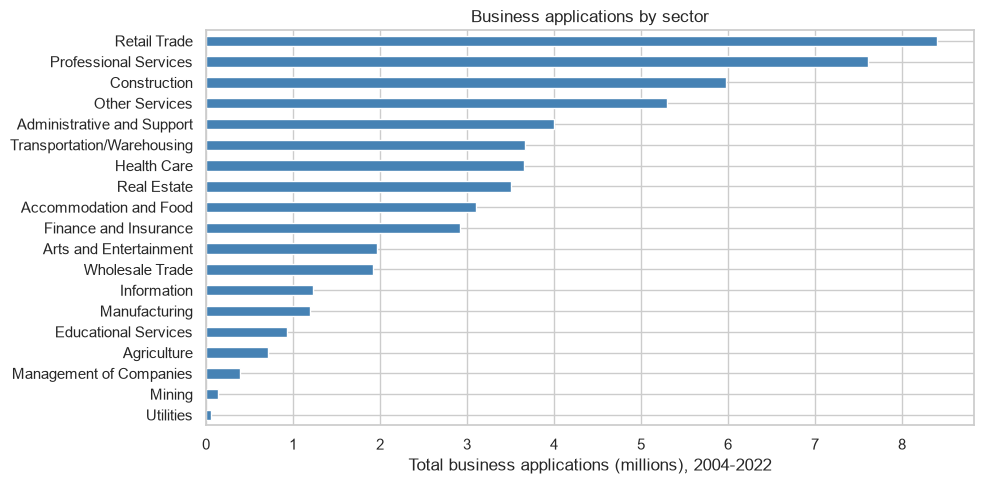

In [221]:
# plot applications by sector

fig, ax = plt.subplots()
sector_apps.plot.barh(ax=ax, color="steelblue")
ax.invert_yaxis()
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1e6:.0f}")
)
ax.set_xlabel("Total business applications (millions), 2004-2022")
ax.set_ylabel("")
ax.set_title("Business applications by sector")
plt.tight_layout()
plt.show()

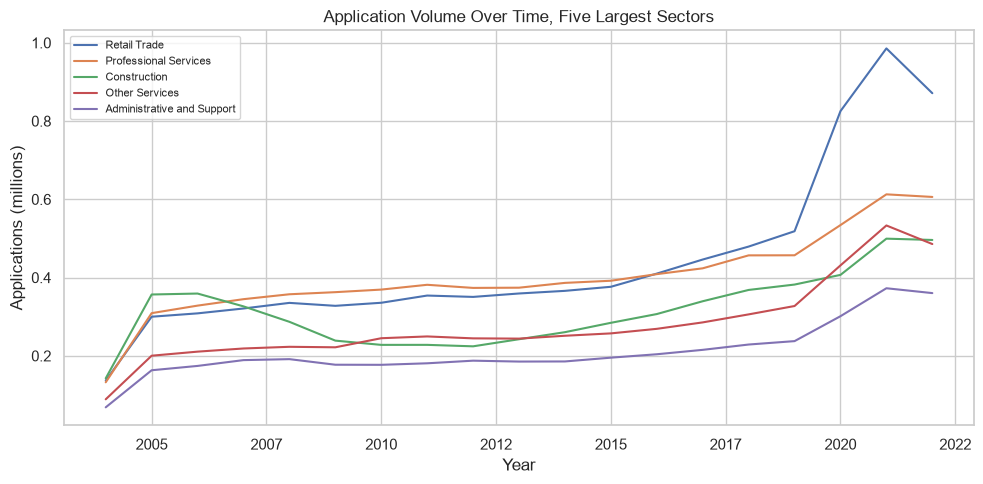

In [222]:
# chart volume year over year for the top sectors
yearly = data.groupby(["year", "sector"])["BA_BA"].sum().unstack()
top_five = sector_apps.head(5).index
fig, ax = plt.subplots()
yearly[top_five].plot(ax=ax)
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, pos: f"{y/1e6:.1f}")
)
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{int(x)}")
)
ax.set_ylabel("Applications (millions)")
ax.set_xlabel("Year")
ax.set_title("Application Volume Over Time, Five Largest Sectors")
ax.legend(title="", fontsize=8)
plt.tight_layout()
plt.show()

### Question 2: Is there a seasonal pattern?

In [223]:
# check ratio relative to same year average
monthly = data.groupby(["year", "month"])["BA_BA"].sum().unstack()
seasonal_index = (
    monthly.div(monthly.mean(axis=1), axis=0).mean()[MONTHS]
)
seasonal_index.round(3)

month
jan    1.012
feb    1.067
mar    1.199
apr    1.079
may    1.045
jun    0.985
jul    0.981
aug    1.003
sep    0.944
oct    0.937
nov    0.910
dec    0.857
dtype: float64

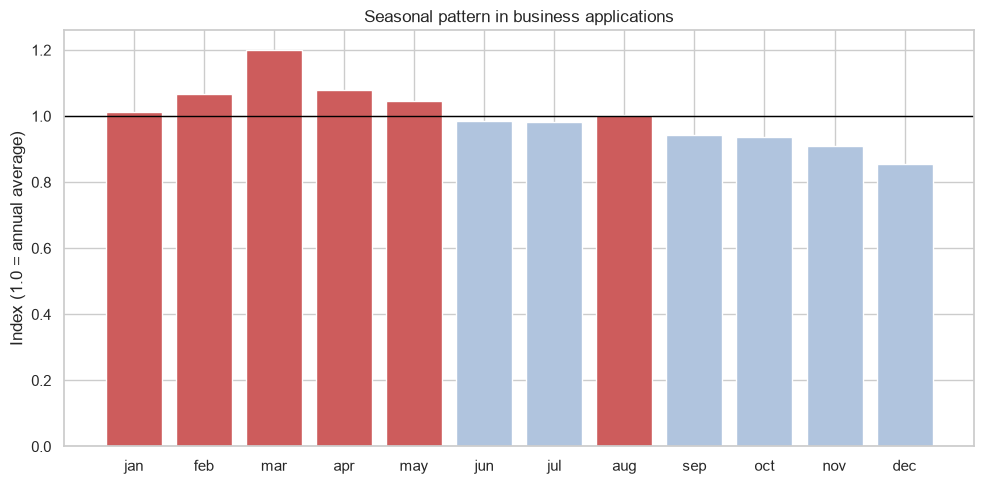

In [224]:
# show seasonal patterns in when applications take place
fig, ax = plt.subplots()
colors = ["indianred" if v >= 1 else "lightsteelblue"
          for v in seasonal_index]
ax.bar(seasonal_index.index, seasonal_index.values, color=colors)
ax.axhline(1.0, color="black", linewidth=1)
ax.set_ylabel("Index (1.0 = annual average)")
ax.set_title("Seasonal pattern in business applications")
plt.tight_layout()
plt.show()

### Question 3: Which sectors convert best?

In [225]:
# see which sectors have the highest conversion rate (application leading to a business formation)
sector_conv = (
    data.groupby("sector")["conversion_rate"]
    .mean()
    .sort_values(ascending=False)
)
sector_conv.round(3)

sector
Accommodation and Food        0.266
Health Care                   0.149
Mining                        0.134
Manufacturing                 0.128
Construction                  0.117
Professional Services         0.112
Wholesale Trade               0.108
Other Services                0.098
Administrative and Support    0.097
Retail Trade                  0.096
Educational Services          0.090
Finance and Insurance         0.077
Transportation/Warehousing    0.073
Real Estate                   0.069
Information                   0.069
Arts and Entertainment        0.069
Utilities                     0.054
Agriculture                   0.029
Management of Companies       0.010
Name: conversion_rate, dtype: float64

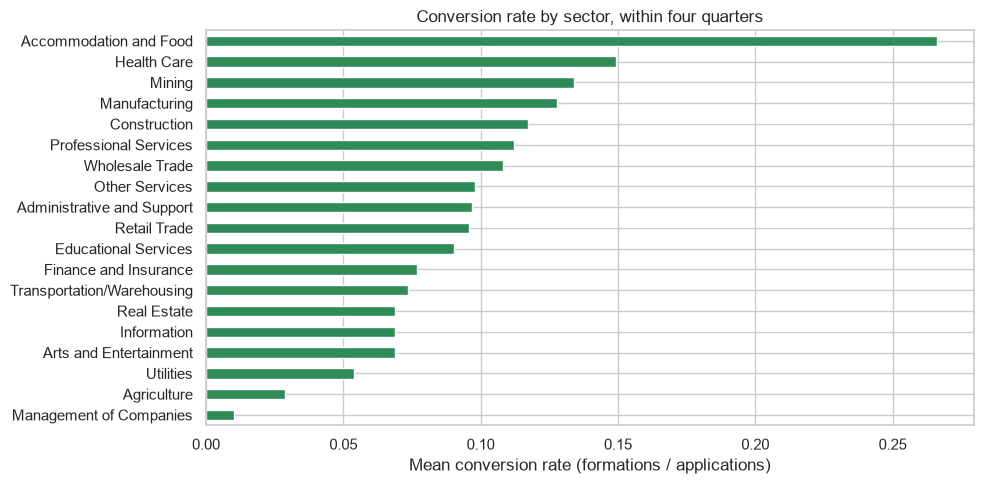

In [226]:
# plot conversion rate findings
fig, ax = plt.subplots()
sector_conv.plot.barh(ax=ax, color="seagreen")
ax.invert_yaxis()
ax.set_xlabel("Mean conversion rate (formations / applications)")
ax.set_ylabel("")
ax.set_title("Conversion rate by sector, within four quarters")
plt.tight_layout()
plt.show()

In [227]:
# compare sector volume and conversion rate rankings
compare = pd.DataFrame({
    "applications": sector_apps,
    "conversion_rate": sector_conv,
})
compare["volume_rank"] = compare["applications"].rank(ascending=False)
compare["conversion_rank"] = compare["conversion_rate"].rank(
    ascending=False
)
compare["rank_gap"] = (
    compare["volume_rank"] - compare["conversion_rank"]
)
compare.sort_values("applications", ascending=False).round(3)

,applications,conversion_rate,volume_rank,conversion_rank,rank_gap
sector,,,,,
Retail Trade,8407149.0,0.096,1.0,10.0,-9.0
Professional Services,7610284.0,0.112,2.0,6.0,-4.0
Construction,5977242.0,0.117,3.0,5.0,-2.0
Other Services,5292996.0,0.098,4.0,8.0,-4.0
Administrative and Support,3995495.0,0.097,5.0,9.0,-4.0
Transportation/Warehousing,3669067.0,0.073,6.0,13.0,-7.0
Health Care,3655007.0,0.149,7.0,2.0,5.0
Real Estate,3502691.0,0.069,8.0,14.0,-6.0
Accommodation and Food,3100998.0,0.266,9.0,1.0,8.0


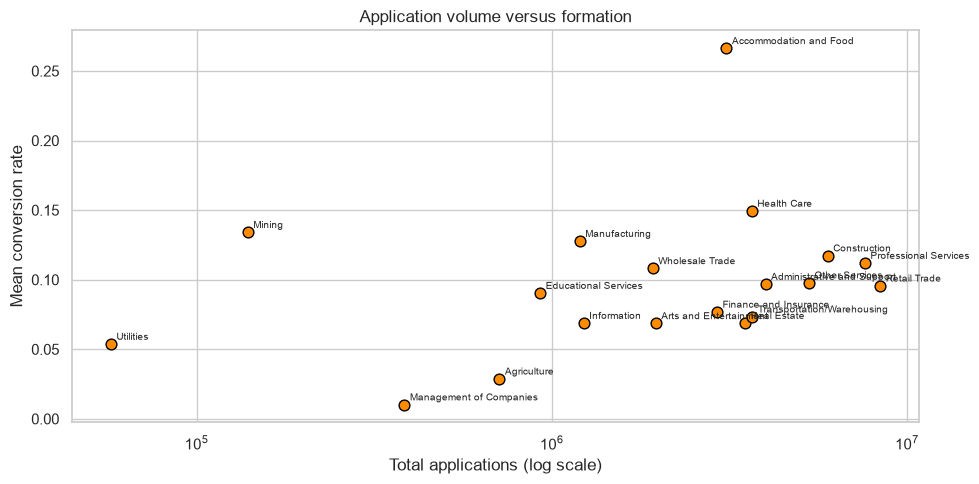

In [228]:
# plot application volume and conversion rate
fig, ax = plt.subplots()
ax.scatter(compare["applications"], compare["conversion_rate"],
           s=60, color="darkorange", edgecolor="black")
for name, row in compare.iterrows():
    ax.annotate(name, (row["applications"], row["conversion_rate"]),
                fontsize=7, xytext=(4, 3), textcoords="offset points")
ax.set_xscale("log")
ax.set_xlabel("Total applications (log scale)")
ax.set_ylabel("Mean conversion rate")
ax.set_title("Application volume versus formation")
plt.tight_layout()
plt.show()

## 4. Machine learning model

**Model choice:** Conversion rate is a continuous variable, so **linear regression** is an appropriate model to use. 

The features we utilize to inform our predictions are sector, month, and the two rate measures calculated previously,
which are planned wage applicant rates and corporate applicant rates.

In [229]:
# establish features and target
FEATURES = ["sector", "month", "wages_share", "corp_share"]
TARGET = "conversion_rate"

model_df = data[FEATURES + [TARGET]].copy()
print("Model frame:", model_df.shape)

Model frame: (4216, 5)


In [230]:
# apply one-hot encoding to sector and month
X = pd.get_dummies(
    model_df[FEATURES], columns=["sector", "month"], drop_first=True
)
y = model_df[TARGET]
print("Feature matrix:", X.shape)

Feature matrix: (4216, 31)


In [231]:
# split for training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape[0], " Test:", X_test.shape[0])

Train: 3372  Test: 844


In [232]:
# fit the model and make predictions
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [233]:
# score the model and showcase results
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R-squared: {r2:.3f}")
print(f"RMSE:      {rmse:.4f}")
print(f"MAE:       {mae:.4f}")

R-squared: 0.943
RMSE:      0.0152
MAE:       0.0109


In [234]:
# compare the model against using the average
baseline = np.full(len(y_test), y_train.mean())
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline))
print(f"Baseline RMSE (predict the mean): {baseline_rmse:.4f}")
print(f"Model RMSE:                       {rmse:.4f}")
print(f"Improvement: {1 - rmse / baseline_rmse:.1%}")

Baseline RMSE (predict the mean): 0.0636
Model RMSE:                       0.0152
Improvement: 76.1%


In [235]:
# highlight the relevant predictors
coefficients = (
    pd.Series(model.coef_, index=X.columns)
    .sort_values(ascending=False)
)
pd.concat([coefficients.head(5), coefficients.tail(5)]).round(4)

wages_share                          0.3092
corp_share                           0.0722
month_jan                            0.0077
month_dec                            0.0044
month_may                            0.0036
sector_Utilities                    -0.1062
sector_Transportation/Warehousing   -0.1078
sector_Information                  -0.1110
sector_Management of Companies      -0.1310
sector_Agriculture                  -0.1653
dtype: float64

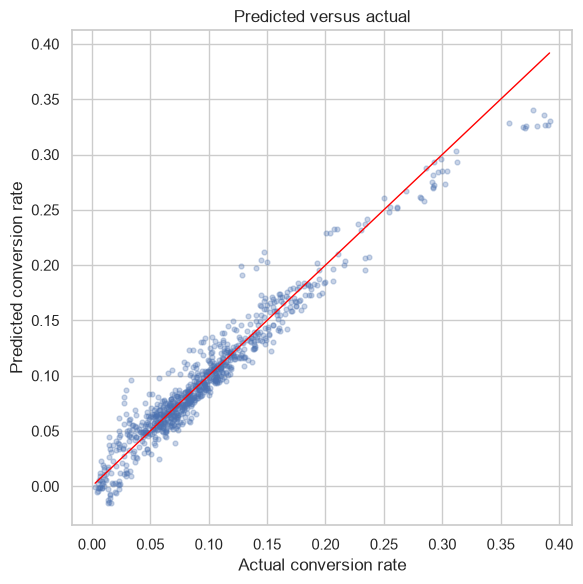

In [236]:
# plot predictions to understand model output
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, alpha=0.3, s=12)
limits = [y_test.min(), y_test.max()]
ax.plot(limits, limits, color="red", linewidth=1)
ax.set_xlabel("Actual conversion rate")
ax.set_ylabel("Predicted conversion rate")
ax.set_title("Predicted versus actual")
plt.tight_layout()
plt.show()

## 5. Prediction scenario

With the limited data we have, we can attempt to make some predictions
for what we might see from these sectors in future years. 

We will predict the conversion rate (and in turn, number of formations) for the
sectors at the two extremes in terms of historical conversion rates. This means the
sector with the highest conversion rate, and the sector with the lowest.

To create our "future-state samples", we will average our features from the
highest volume month for these sectors historically. That way, our samples won't be
an exact match of any past records, but will be logically grounded.

In [237]:
# pick out the best and worst sectors on conversion rate (out of high volume ones)
TOP_SECTORS = 10

leaders = sector_apps.head(TOP_SECTORS).index
ranked = sector_conv[sector_conv.index.isin(leaders)]
best_converter = ranked.idxmax()
worst_converter = ranked.idxmin()
print("Strongest converter:", best_converter)
print("Weakest converter:  ", worst_converter)

Strongest converter: Accommodation and Food
Weakest converter:   Real Estate


In [238]:
# get averages for key features
selected = [best_converter, worst_converter]
picked = data[data["sector"].isin(selected)]

composition = (
    picked.groupby("sector")[["wages_share", "corp_share"]].mean()
)
monthly_volume = (
    picked.groupby(["sector", "month"])["BA_BA"].mean().unstack()[MONTHS]
)
composition.round(4)

,wages_share,corp_share
sector,,
Accommodation and Food,0.4491,0.2500
Real Estate,0.1153,0.1855


In [239]:
# create our prediction scenarios, highest application month and the averages for that month
scenario = pd.DataFrame({
    "sector": selected,
    "month": [monthly_volume.loc[s].idxmax() for s in selected],
    "applications": [
        monthly_volume.loc[s].max().round() for s in selected
    ],
})
scenario = scenario.join(composition, on="sector")
scenario.round(4)

,sector,month,applications,wages_share,corp_share
0,Accommodation and Food,mar,16613.0,0.4491,0.2500
1,Real Estate,mar,19202.0,0.1153,0.1855


In [240]:
# add encoding
scenario_encoded = pd.get_dummies(
    scenario, columns=["sector", "month"], drop_first=False
)
scenario_encoded = scenario_encoded.reindex(
    columns=X.columns, fill_value=0
)
print("Aligned to training columns:", scenario_encoded.shape)

Aligned to training columns: (2, 31)


In [241]:
# make predictions on scenarios, and show predictions in base units (number of successful formations)
scenario["predicted_rate"] = model.predict(scenario_encoded)
scenario["expected_formations"] = (
    scenario["predicted_rate"] * scenario["applications"]
).round(0)

scenario[["sector", "month", "applications", "predicted_rate",
          "expected_formations"]].round(4)

,sector,month,applications,predicted_rate,expected_formations
0,Accommodation and Food,mar,16613.0,0.2626,4363.0
1,Real Estate,mar,19202.0,0.0663,1273.0


## Findings

1. **Volume is concentrated in a few sectors.** Retail Trade and
   Professional Services stand alone as having the most applications. 
   Business application sector volume is largely consistent year over year.
2. **Applications are somewhat seasonal.** Applications are most abundant
   in Q1, and the first half of the year in general. They tend to tail off
   in the back half of the year, especially around year end.
3. **Application volume and formation don't necessarily align within sectors.** 
   Accommodation and Food Services converts at ~27% while Management of
   Companies converts ~1%. High-volume sectors by application tend to sit 
   in the middle of the pack in terms of conversion rate.
4. **Conversion is largely predictable.** Sector, month, and a few key
   application traits (planned wages and corporation status) explain 
   ~93% of the variance in conversion rate. Planned wage rate was the strongest
   positive predictor, meaning if an applicant has signified an intent to pay wages,
   they are far more likely to become a business in the end.
5. **Sector truly matters in successful formation.** When we created hypothetical
   scenarios with the highest and lowest performing historical sectors, we saw a vast 
   difference in formations. Despite Real Estate having 19.2k applicants in our simulated month,
   and Accommodation and Food having 16.6k, the latter produces more than 3 times as many businesses
   based on our model's prediction. This would be an interesting finding to expand upon with more robust
   data, as these attempted business types may have vastly different goals and expectations.

**Limitations.** 
-  State-level analysis cannot be conducted reliably, as sector-level data is only
   recorded at the national level. Having to pick one lane likely reduced the model's 
   effectiveness. 
-  True formation measurements end in 2022, so the past 3.5 years of data are not evaluated.
-  Historical context is largely ignored, despite changing market conditions throughout
   the timeline of the analysis.